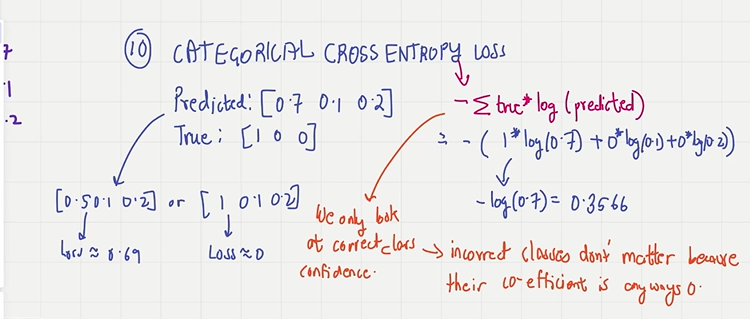

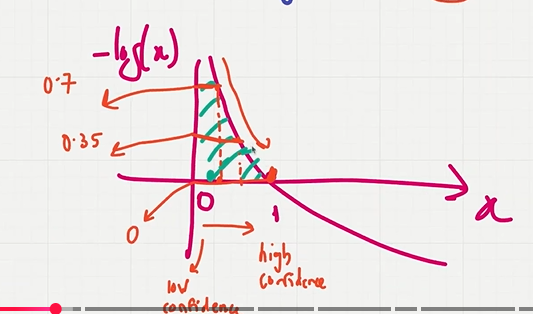

In [79]:
from IPython.display import Image, display
display(Image(filename='crossE.png'))
display(Image(filename='logloss.png'))

in above picture, probability always lies between 0 and 1. high confidence when loss is near 0 and high when near 1.
This loss, categorical cross entropy loss is used in classification. and since we are working with spiral data, there needs to be classification.

The below image shows how in the given case, we can find out the loss.

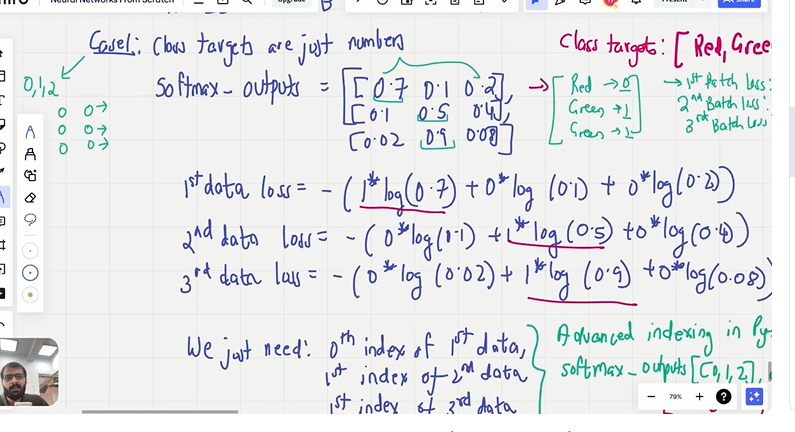

In [81]:
display(Image(filename='losscase1.png'))

so, in python to implement this particular logic, we use advance indexing in softmax outputs [0,1,1] and it results 
in the desired outputs, and then we do -log of the output array. This array/matrix is also called, negetive log likelihood.
And perform mean of them to get the final cumilative loss.

In [83]:
import numpy as np
softmax_outputs_array=np.array([
    [0.7,0.2,0.1],
    [0.1, 0.5, 0.4],
    [0.08,0.9,0.02]])
class_targets=[0,1,1]
print(softmax_outputs_array[[0,1,2], class_targets])
#the above print statement with softmax array with two outputs will result in
#3 points, [0,1] [1,1] [1,2] 
import numpy as np
print(-np.log(softmax_outputs_array[range(len(softmax_outputs_array)), class_targets]))
neg_log=-np.log(softmax_outputs_array[range(len(softmax_outputs_array)), class_targets])
cumilative_loss= np.mean(neg_log)
print(cumilative_loss)

[0.7 0.5 0.9]
[0.35667494 0.69314718 0.10536052]
0.38506088005216804


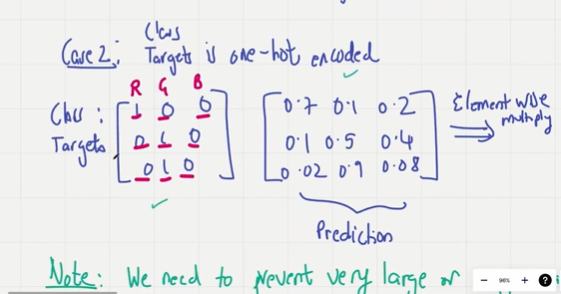

In [84]:
display(Image(filename='logcase2.png'))

In the above case, we dont get class targets in an array, but we get them as a matrix.
so we do element wise multiplications and reach our desired results, after summing and following the case 1 methodologies. as shown in below img

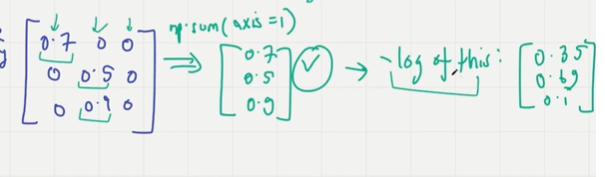

In [86]:
display(Image(filename='logcasse2.png'))

In [87]:
y_true_check = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 1, 0]
])

y_pred_clipped_check = np.array([
    [0.7, 0.2, 0.1],
    [0.1, 0.5, 0.4],
    [0.02, 0.9, 0.08]
])

A = y_true_check*y_pred_clipped_check
B = np.sum(A, axis = 1)
C = - np.log(B)

print(C)
print(np.mean(C))

[0.35667494 0.69314718 0.10536052]
0.38506088005216804


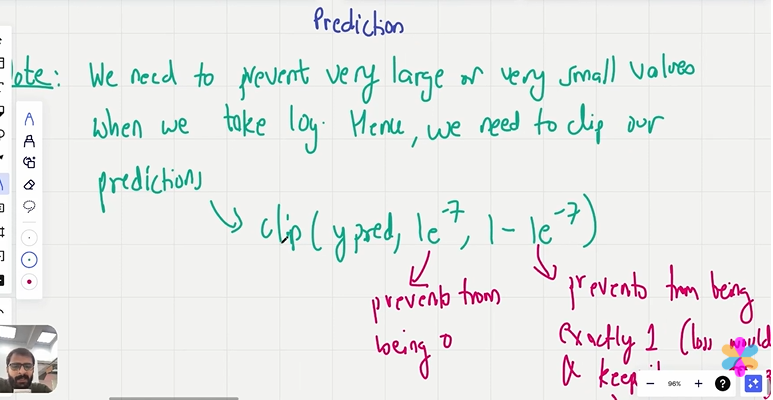

In [88]:
#Since we dont want out outputs to be 0 or exactly 1, we perform clipping.
display(Image(filename='clipping.png'))

In [97]:
#now we didnt want the above to return mean, since we also want the likelihood matrix, so we go ahead with another class for the same
#as in above class, Loss is a parameter, which is another class that we are creating rn, but it will be able to acces all the methods of above class, as 
#it has been called as an argument, whenever an instance of above class is creater. tHE BELOW IS SAVED IN CLASSES.PY

# Common loss class
class Loss:
 # Calculates the data and regularization losses
 # given model output and ground truth values
 def calculate(self, output, y):
  # Calculate sample losses
  sample_losses = self.forward(output, y)
  # Calculate mean loss
  data_loss = np.mean(sample_losses)
  # Return loss
  return data_loss

In [99]:
#now we are creating a class that can perform the cross entropy loss. we will also save it in classes.py

# Cross-entropy loss
class Loss_CategoricalCrossentropy(Loss):
 # Forward pass
 def forward(self, y_pred, y_true):
  # Number of samples in a batch
  samples = len(y_pred)
  # Clip data to prevent division by 0
  # Clip both sides to not drag mean towards any value
  y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
  # Probabilities for target values -
  # only if categorical labels
  if len(y_true.shape) == 1: # this tells if our data is normal or hot encoded. if shape is not 1, its hot encoded.
   correct_confidences = y_pred_clipped[
   range(samples),
   y_true
   ]
  # Mask values - only for one-hot encoded labels
  elif len(y_true.shape) == 2:
   correct_confidences = np.sum(
   y_pred_clipped*y_true,
   axis=1
   )
 # Losses
  negative_log_likelihoods = -np.log(correct_confidences)
  return negative_log_likelihoods

In [101]:
#NOW WE WILL USE THE ABOVE DECLARED CLASSES, TO FIND OUR LOSS.

softmax_outputs = np.array([[0.7, 0.1, 0.2],
 [0.1, 0.5, 0.4],
 [0.02, 0.9, 0.08]])
class_targets = np.array([[1, 0, 0],
 [0, 1, 0],
 [0, 1, 0]])
loss_function = Loss_CategoricalCrossentropy()
loss = loss_function.calculate(softmax_outputs, class_targets)
print(loss)

0.38506088005216804


FULL CODE UPTO THIS POINT, WE WILL IMPORT ALL CLASSES FROM CLASSES.PY

In [106]:
from CLASSES import Layer_Dense, Activation_ReLU, Activation_Softmax
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()
# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)
# Create ReLU activation (to be used with Dense layer):
activation1 = Activation_ReLU()
# Create second Dense layer with 3 input features (as we take output
# of previous layer here) and 3 output values
dense2 = Layer_Dense(3, 3)
# Create Softmax activation (to be used with Dense layer):
activation2 = Activation_Softmax()
# Create loss function
loss_function = Loss_CategoricalCrossentropy()


# Perform a forward pass of our training data through this layer
dense1.forward(X)
# Perform a forward pass through activation function
# it takes the output of first dense layer here
activation1.forward(dense1.output)

# Perform a forward pass through second Dense layer
# it takes outputs of activation function of first layer as inputs
dense2.forward(activation1.output)
# Perform a forward pass through activation function
# it takes the output of second dense layer here
activation2.forward(dense2.output)
# Let's see output of the first few samples:
print(activation2.output[:5])
# Perform a forward pass through activation function
# it takes the output of second dense layer here and returns loss
loss = loss_function.calculate(activation2.output, y)
# Print loss value
print('loss:', loss)

# Calculate accuracy from output of activation2 and targets
# calculate values along first axis
predictions = np.argmax(activation2.output, axis=1)
if len(y.shape) == 2:
 y = np.argmax(y, axis=1)
accuracy = np.mean(predictions == y)
# Print accuracy
print('acc:', accuracy)

[[0.33333334 0.33333334 0.33333334]
 [0.3333332  0.3333332  0.33333364]
 [0.3333329  0.33333293 0.3333342 ]
 [0.3333326  0.33333263 0.33333477]
 [0.33333233 0.3333324  0.33333528]]
loss: 1.0986104
acc: 0.34


INTRODUCTING ACCURACY:
it, basically how many times our class targets, were equal to what the output of the row was supposed to be. 
In below example, in the first row, output was 0th index, and the class target matched it. So it gave 100% and so for other rows, and then a mean on
all accuracies is performed. to give final. here all are correct, so it has 100% accuracy.

Its, not really a great metric, but in large models, we plot accuracy. 

In [108]:
import numpy as np
# Probabilities of 3 samples
softmax_outputs = np.array([[0.7, 0.2, 0.1],
 [0.1, 0.5, 0.4],
 [0.02, 0.9, 0.08]])
# Target (ground-truth) labels for 3 samples
class_targets = np.array([0, 1, 1])
# Calculate values along second axis (axis of index 1)
predictions = np.argmax(softmax_outputs, axis=1)
# If targets are one-hot encoded - convert them
if len(class_targets.shape) == 2:
 class_targets = np.argmax(class_targets, axis=1)
# True evaluates to 1; False to 0
accuracy = np.mean(predictions == class_targets)
print('acc:', accuracy)

acc: 1.0
